# 🚗 Driver Drowsiness Detection
**Binary classification: Alert vs Drowsy**

Three models compared:
1. Baseline CNN
2. Advanced CNN (BatchNorm + L2 + GlobalAvgPool)
3. MobileNetV2 (Transfer Learning)

**Pipeline:** Record videos → Extract frames → Train → Evaluate → Streamlit app

## 0. Install Dependencies

In [1]:
!pip install torch torchvision opencv-python matplotlib scikit-learn seaborn Pillow streamlit -q

## 1. Imports and Configuration

In [3]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models as tv_models
from torchvision.datasets import ImageFolder
from PIL import Image
from pathlib import Path

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.11.0+cpu
Device: cpu


In [7]:
# Paths 
BASE_DIR   = Path(".")
FRAMES_DIR = BASE_DIR / "dataset" / "frames"
SAVED_DIR  = BASE_DIR / "saved_models"
LOGS_DIR   = BASE_DIR / "logs"
EVAL_DIR   = BASE_DIR / "evaluation_plots"

for d in [SAVED_DIR, LOGS_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Image / training config
IMG_SIZE     = 96
IMG_CHANNELS = 1       # grayscale
CLASSES      = ["alert", "drowsy"]   # alphabetical = ImageFolder default
BATCH_SIZE   = 32
EPOCHS       = 40
SEED         = 42
VAL_SPLIT    = 0.2

torch.manual_seed(SEED)
np.random.seed(SEED)

print("Configuration ready.")
print(f"  Input shape : ({IMG_CHANNELS}, {IMG_SIZE}, {IMG_SIZE})")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Max epochs  : {EPOCHS}")

Configuration ready.
  Input shape : (1, 96, 96)
  Batch size  : 32
  Max epochs  : 40


## Datset - Extract Frames from Videos

The cell below extracts frames at 5 fps and saves them as 96×96 grayscale JPEGs.  
**Aim for 500–1000+ frames per class.**

In [77]:
def extract_frames(video_path, output_dir, target_fps=5, size=96):
    """Extract frames from a video at target_fps, resize to size×size grayscale."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  [!] Cannot open: {video_path}")
        return 0

    source_fps = cap.get(cv2.CAP_PROP_FPS) or 30
    frame_interval = max(1, int(source_fps / target_fps))
    video_name = Path(video_path).stem
    saved, idx = 0, 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % frame_interval == 0:
            frame = cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
            gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (size, size))
            fname   = output_dir / f"{video_name}_f{idx:06d}.jpg"
            cv2.imwrite(str(fname), resized)
            saved += 1
        idx += 1

    cap.release()
    return saved

# Run extraction
TARGET_FPS = 5

for label in CLASSES:
    in_dir  = BASE_DIR / "dataset" / "videos" / label
    out_dir = FRAMES_DIR / label
    out_dir.mkdir(parents=True, exist_ok=True)

    if not in_dir.exists():
        print(f"[WARN] {in_dir} not found — skipping.")
        continue

    video_files = list(in_dir.glob("*.mp4")) + list(in_dir.glob("*.avi")) \
                + list(in_dir.glob("*.mov")) + list(in_dir.glob("*.mkv"))

    if not video_files:
        print(f"[WARN] No videos in {in_dir}")
        continue

    print(f"\n[{label.upper()}] {len(video_files)} video(s)...")
    total = 0
    for vf in video_files:
        n = extract_frames(vf, out_dir, target_fps=TARGET_FPS, size=IMG_SIZE)
        print(f"  {vf.name}: {n} frames")
        total += n
    print(f"  → Subtotal: {total} frames")

print("\n── Class balance ──────────────────────────────────────")
for label in CLASSES:
    d = FRAMES_DIR / label
    n = len(list(d.glob("*.jpg"))) if d.exists() else 0
    print(f"  {label:10s}: {n:5d} frames")


[ALERT] 9 video(s)...
  alert_01.mp4: 603 frames
  alert_02.mp4: 95 frames
  alert_03.mp4: 222 frames
  alert_04.mp4: 267 frames
  alert_05.mp4: 303 frames
  alert_06.mp4: 221 frames
  alert_07.mp4: 77 frames
  alert_08.mp4: 185 frames
  alert_09.mp4: 120 frames
  → Subtotal: 2093 frames

[DROWSY] 8 video(s)...
  drowsy_01.mp4: 448 frames
  drowsy_02.mp4: 202 frames
  drowsy_03.mp4: 325 frames
  drowsy_04.mp4: 103 frames
  drowsy_05.mp4: 204 frames
  drowsy_06.mp4: 320 frames
  drowsy_07.mp4: 409 frames
  drowsy_08.mp4: 200 frames
  → Subtotal: 2211 frames

── Class balance ──────────────────────────────────────
  alert     :  2093 frames
  drowsy    :  2211 frames


### Preview Extracted Frames

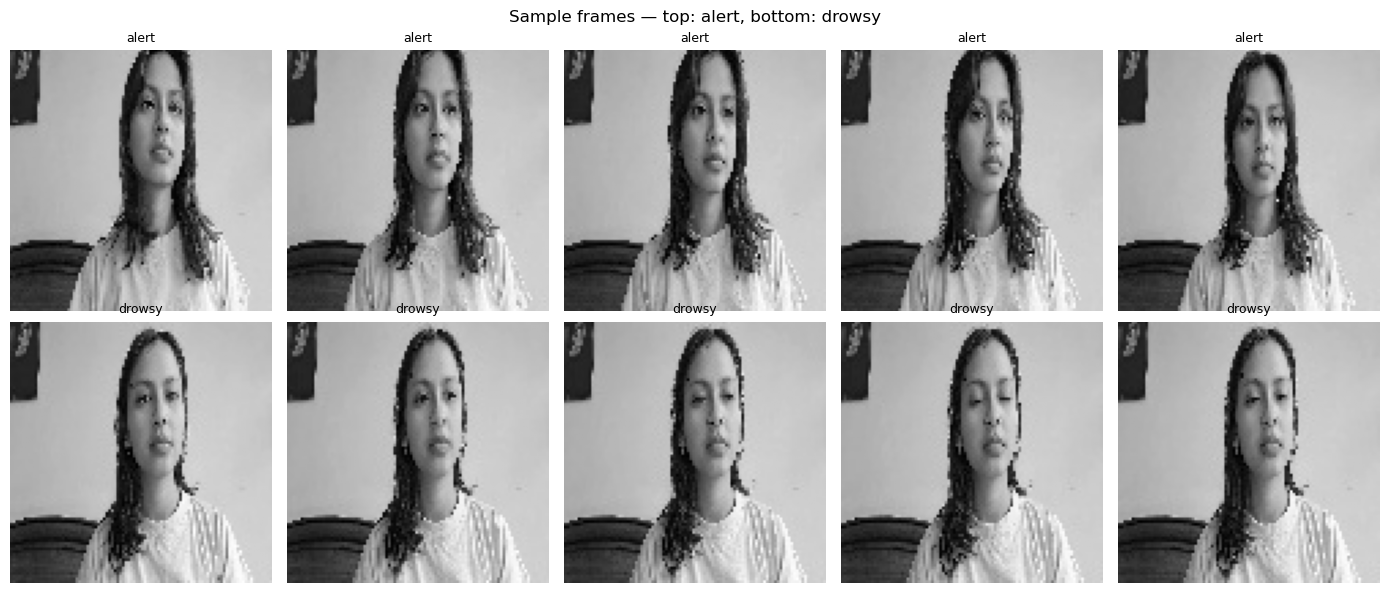

In [79]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample frames — top: alert, bottom: drowsy", fontsize=12)

for row, label in enumerate(CLASSES):
    d = FRAMES_DIR / label
    imgs = sorted(d.glob("*.jpg"))[:5] if d.exists() else []
    for col in range(5):
        ax = axes[row][col]
        if col < len(imgs):
            img = cv2.imread(str(imgs[col]), cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap="gray")
            ax.set_title(label, fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Data Loaders

In [81]:
def build_transforms(augment=True):
    """Returns (train_transform, val_transform)."""
    val_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    if augment:
        train_transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ColorJitter(brightness=0.2),
            transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])
    else:
        train_transform = val_transform

    return train_transform, val_transform


def build_loaders(augment=True):
    """Returns (train_loader, val_loader, class_to_idx)."""
    train_tf, val_tf = build_transforms(augment=augment)

    full_dataset = ImageFolder(root=str(FRAMES_DIR), transform=train_tf)
    n_total = len(full_dataset)
    n_val   = int(n_total * VAL_SPLIT)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(SEED)
    train_subset, val_subset = random_split(full_dataset, [n_train, n_val], generator=generator)

    # Apply val transform to the validation split
    val_subset.dataset = ImageFolder(root=str(FRAMES_DIR), transform=val_tf)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    return train_loader, val_loader, full_dataset.class_to_idx


def get_class_weights(train_loader):
    """Compute balanced class weights from training data."""
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.numpy())
    all_labels = np.array(all_labels)
    unique = np.unique(all_labels)
    weights = compute_class_weight("balanced", classes=unique, y=all_labels)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


# Build them now — reuse throughout training
train_loader, val_loader, class_to_idx = build_loaders(augment=True)
class_weights = get_class_weights(train_loader)

print("Class indices :", class_to_idx)
print("Class weights :", class_weights)
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Class indices : {'alert': 0, 'drowsy': 1}
Class weights : tensor([1.0088, 0.9914])
Train batches : 108
Val batches   : 27


## 4. Shared Training Loop and Utilities

In [28]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def train_model(name, model, train_loader, val_loader,
                epochs=EPOCHS, lr=1e-3,
                patience_es=10, patience_lr=5,
                weight_pos=None):
    """
    Full training loop with:
    - BCEWithLogitsLoss (pos_weight for class imbalance)
    - ReduceLROnPlateau scheduler
    - Early stopping
    - Best-model checkpointing
    Returns history dict.
    """
    model.to(DEVICE)

    pos_weight = weight_pos  # tensor([w]) or None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5,
        patience=patience_lr, min_lr=1e-7
    )

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    best_val_acc = 0.0
    no_improve   = 0
    best_path    = str(SAVED_DIR / f"{name}_best.pt")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_loss)

        history["loss"].append(t_loss)
        history["accuracy"].append(t_acc)
        history["val_loss"].append(v_loss)
        history["val_accuracy"].append(v_acc)

        print(f"Epoch {epoch:3d}/{epochs}  "
              f"loss={t_loss:.4f}  acc={t_acc:.4f}  "
              f"val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), best_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_es:
                print(f"  Early stopping at epoch {epoch}.")
                break

    # Restore best weights
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    np.save(str(LOGS_DIR / f"{name}_history.npy"), history)
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
    return history


print("Training utilities ready.")

Training utilities ready.


## 5. Model 1 - Baseline CNN
Simple 3-block CNN. Light regularisation with Dropout only.  
This is the **reference** — we improve on it in Models 2 and 3.

In [83]:
class BaselineCNN(nn.Module):
    """
    3 × [Conv → MaxPool → Dropout]  →  Dense(128) → Dropout(0.5) → sigmoid
    Regularisation: Dropout only (0.25 after each pool, 0.5 before output).
    """
    def __init__(self, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        # After 3×MaxPool2d(2) on 96×96 → 12×12
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 128), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),   # raw logit — BCEWithLogitsLoss handles sigmoid
        )

    def forward(self, x):
        return self.classifier(self.features(x))


baseline_model = BaselineCNN(in_channels=IMG_CHANNELS)
print(baseline_model)
total_params = sum(p.numel() for p in baseline_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 2,452,225


In [85]:
train_loader, val_loader, _ = build_loaders(augment=True)
class_weights = get_class_weights(train_loader)
# pos_weight = weight for class 1 (drowsy) relative to class 0 (alert)
pos_weight = (class_weights[1] / class_weights[0]).unsqueeze(0)

print("Training Baseline CNN...")
baseline_history = train_model(
    "baseline_cnn", baseline_model,
    train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3,
    patience_es=10, patience_lr=5,
    weight_pos=pos_weight,
)

Training Baseline CNN...
Epoch   1/40  loss=0.5558  acc=0.6957  val_loss=0.3759  val_acc=0.8860
Epoch   2/40  loss=0.4301  acc=0.8014  val_loss=0.2027  val_acc=0.9733
Epoch   3/40  loss=0.3341  acc=0.8589  val_loss=0.1510  val_acc=0.9767
Epoch   4/40  loss=0.2790  acc=0.8821  val_loss=0.1010  val_acc=0.9802
Epoch   5/40  loss=0.2562  acc=0.8952  val_loss=0.0495  val_acc=0.9895
Epoch   6/40  loss=0.2087  acc=0.9106  val_loss=0.0587  val_acc=0.9872
Epoch   7/40  loss=0.1811  acc=0.9286  val_loss=0.0203  val_acc=0.9953
Epoch   8/40  loss=0.1775  acc=0.9283  val_loss=0.0204  val_acc=0.9942
Epoch   9/40  loss=0.1521  acc=0.9413  val_loss=0.0218  val_acc=0.9930
Epoch  10/40  loss=0.1398  acc=0.9437  val_loss=0.0173  val_acc=0.9965
Epoch  11/40  loss=0.1241  acc=0.9518  val_loss=0.0161  val_acc=0.9953
Epoch  12/40  loss=0.1102  acc=0.9602  val_loss=0.0089  val_acc=0.9977
Epoch  13/40  loss=0.1036  acc=0.9611  val_loss=0.0058  val_acc=0.9988
Epoch  14/40  loss=0.1106  acc=0.9593  val_loss=0.01

## 6. Model 2 - Advanced CNN
Improvements over baseline:
- **BatchNormalization** after every Conv layer (stabilises training, acts as regulariser)
- **L2 weight regularisation** via `weight_decay` in the optimizer
- **Global Average Pooling** instead of Flatten — cuts parameters, reduces overfitting
- Deeper architecture (4 blocks, double conv per block)
- Stronger Dropout schedule

In [87]:
class ConvBnRelu(nn.Module):
    """Conv → BatchNorm → ReLU building block."""
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class AdvancedCNN(nn.Module):
    """
    4 × [Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout]
    → GlobalAveragePooling
    → Dense(256)→BN→ReLU→Dropout(0.5)
    → Dense(128)→BN→ReLU→Dropout(0.4)
    → logit (1 output)
    """
    def __init__(self, in_channels=1):
        super().__init__()
        self.block1 = nn.Sequential(
            ConvBnRelu(in_channels, 32), ConvBnRelu(32, 32),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.block2 = nn.Sequential(
            ConvBnRelu(32, 64), ConvBnRelu(64, 64),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.block3 = nn.Sequential(
            ConvBnRelu(64, 128), ConvBnRelu(128, 128),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
        )
        self.block4 = nn.Sequential(
            ConvBnRelu(128, 256), ConvBnRelu(256, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)   # Global Average Pooling

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.head(x)


advanced_model = AdvancedCNN(in_channels=IMG_CHANNELS)
print(advanced_model)
baseline_params = sum(p.numel() for p in baseline_model.parameters())
advanced_params = sum(p.numel() for p in advanced_model.parameters())
print(f"\nBaseline params : {baseline_params:,}")
print(f"Advanced params : {advanced_params:,}  (fewer = less overfitting risk via GAP)")

AdvancedCNN(
  (block1): Sequential(
    (0): ConvBnRelu(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBnRelu(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): ConvBnRelu(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inpl

In [89]:
train_loader, val_loader, _ = build_loaders(augment=True)
class_weights = get_class_weights(train_loader)
pos_weight = (class_weights[1] / class_weights[0]).unsqueeze(0)

print("Training Advanced CNN...")
# L2 regularisation is applied via weight_decay in Adam (equivalent to L2 penalty)
advanced_model.to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(advanced_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-7
)
advanced_history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_acc, no_improve = 0.0, 0
best_path = str(SAVED_DIR / "advanced_cnn_best.pt")

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(advanced_model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate(advanced_model, val_loader, criterion)
    scheduler.step(v_loss)

    advanced_history["loss"].append(t_loss)
    advanced_history["accuracy"].append(t_acc)
    advanced_history["val_loss"].append(v_loss)
    advanced_history["val_accuracy"].append(v_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS}  loss={t_loss:.4f}  acc={t_acc:.4f}  "
          f"val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(advanced_model.state_dict(), best_path)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= 10:
            print(f"  Early stopping at epoch {epoch}.")
            break

advanced_model.load_state_dict(torch.load(best_path, map_location=DEVICE))
np.save(str(LOGS_DIR / "advanced_cnn_history.npy"), advanced_history)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Training Advanced CNN...
Epoch   1/40  loss=0.6391  acc=0.6402  val_loss=0.5824  val_acc=0.6895
Epoch   2/40  loss=0.6078  acc=0.6632  val_loss=0.5653  val_acc=0.6279
Epoch   3/40  loss=0.5819  acc=0.6777  val_loss=0.5301  val_acc=0.8535
Epoch   4/40  loss=0.5732  acc=0.6992  val_loss=0.5035  val_acc=0.7326
Epoch   5/40  loss=0.5364  acc=0.7201  val_loss=0.4347  val_acc=0.7919
Epoch   6/40  loss=0.5055  acc=0.7454  val_loss=0.3531  val_acc=0.8419
Epoch   7/40  loss=0.4690  acc=0.7668  val_loss=0.2786  val_acc=0.8640
Epoch   8/40  loss=0.4329  acc=0.7883  val_loss=0.3552  val_acc=0.8349
Epoch   9/40  loss=0.3780  acc=0.8136  val_loss=0.2659  val_acc=0.8616
Epoch  10/40  loss=0.3640  acc=0.8211  val_loss=0.2591  val_acc=0.8733
Epoch  11/40  loss=0.3446  acc=0.8316  val_loss=0.1854  val_acc=0.8826
Epoch  12/40  loss=0.2956  acc=0.8641  val_loss=0.1631  val_acc=0.9523
Epoch  13/40  loss=0.2685  acc=0.8754  val_loss=0.1316  val_acc=0.9640
Epoch  14/40  loss=0.2303  acc=0.9030  val_loss=0.09

## 7. Model 3 - MobileNetV2 (Transfer Learning)
**Strategy:**
- **Phase 1** - Freeze the entire MobileNetV2 base, train only the custom head (~5–10 epochs). Fast and safe - no risk of destroying pre-trained features.
- **Phase 2** - Unfreeze the top layers and fine-tune at a very low learning rate (1e-5).

The base is adapted from RGB to grayscale by repeating the single channel to 3 channels.

In [93]:
class MobileNetV2Drowsiness(nn.Module):
    """
    MobileNetV2 backbone with a custom classification head.
    Input: single-channel (grayscale) images — repeated to 3 channels internally.
    """
    def __init__(self, freeze_base=True):
        super().__init__()
        # Load pretrained MobileNetV2
        backbone = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features   # output: (batch, 1280, H/32, W/32)

        if freeze_base:
            for param in self.features.parameters():
                param.requires_grad = False

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # Grayscale → 3-channel (repeat channel)
        x = x.repeat(1, 3, 1, 1)
        x = self.features(x)
        x = self.gap(x)
        return self.head(x)

    def unfreeze_top_layers(self, n_layers_to_unfreeze=54):
        """Unfreeze the last n feature blocks for fine-tuning."""
        feature_layers = list(self.features.children())
        total = len(feature_layers)
        freeze_up_to = total - n_layers_to_unfreeze
        for i, layer in enumerate(feature_layers):
            for param in layer.parameters():
                param.requires_grad = (i >= freeze_up_to)
        unfrozen = sum(1 for p in self.features.parameters() if p.requires_grad)
        print(f"  Unfrozen feature params: {unfrozen}")


mobilenet_model = MobileNetV2Drowsiness(freeze_base=True)
mobilenet_model.to(DEVICE)
print(mobilenet_model)

MobileNetV2Drowsiness(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2

In [95]:
# Rebuild loaders with 3-channel-compatible grayscale (model repeats internally)
train_loader, val_loader, _ = build_loaders(augment=True)
class_weights = get_class_weights(train_loader)
pos_weight = (class_weights[1] / class_weights[0]).unsqueeze(0)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Phase 1: train head only 
PHASE1_EPOCHS = 15
print(f"Phase 1: training head only for up to {PHASE1_EPOCHS} epochs...")

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=1e-3
)
scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode="min", factor=0.5, patience=3, min_lr=1e-7
)

history_p1 = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_acc, no_improve = 0.0, 0
best_path_p1 = str(SAVED_DIR / "mobilenet_v2_phase1_best.pt")

for epoch in range(1, PHASE1_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(mobilenet_model, train_loader, criterion, optimizer_p1)
    v_loss, v_acc = evaluate(mobilenet_model, val_loader, criterion)
    scheduler_p1.step(v_loss)

    for k, v in zip(["loss","accuracy","val_loss","val_accuracy"],
                    [t_loss, t_acc, v_loss, v_acc]):
        history_p1[k].append(v)

    print(f"[P1] Epoch {epoch:3d}/{PHASE1_EPOCHS}  loss={t_loss:.4f}  acc={t_acc:.4f}  "
          f"val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(mobilenet_model.state_dict(), best_path_p1)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= 7:
            print(f"  Early stopping at epoch {epoch}.")
            break

mobilenet_model.load_state_dict(torch.load(best_path_p1, map_location=DEVICE))

Phase 1: training head only for up to 15 epochs...
[P1] Epoch   1/15  loss=0.4402  acc=0.7895  val_loss=0.2367  val_acc=0.9116
[P1] Epoch   2/15  loss=0.3010  acc=0.8682  val_loss=0.1750  val_acc=0.9267
[P1] Epoch   3/15  loss=0.2877  acc=0.8786  val_loss=0.1784  val_acc=0.9291
[P1] Epoch   4/15  loss=0.2574  acc=0.8949  val_loss=0.1786  val_acc=0.9221
[P1] Epoch   5/15  loss=0.2507  acc=0.8940  val_loss=0.1531  val_acc=0.9372
[P1] Epoch   6/15  loss=0.2308  acc=0.9033  val_loss=0.1265  val_acc=0.9465
[P1] Epoch   7/15  loss=0.2123  acc=0.9056  val_loss=0.1170  val_acc=0.9523
[P1] Epoch   8/15  loss=0.2042  acc=0.9149  val_loss=0.0933  val_acc=0.9605
[P1] Epoch   9/15  loss=0.2021  acc=0.9167  val_loss=0.0907  val_acc=0.9663
[P1] Epoch  10/15  loss=0.2024  acc=0.9178  val_loss=0.1165  val_acc=0.9605
[P1] Epoch  11/15  loss=0.1892  acc=0.9236  val_loss=0.1323  val_acc=0.9453
[P1] Epoch  12/15  loss=0.1911  acc=0.9199  val_loss=0.1041  val_acc=0.9535
[P1] Epoch  13/15  loss=0.1770  acc=0

<All keys matched successfully>

In [97]:
# Phase 2: unfreeze top layers, fine-tune
print("\nPhase 2: fine-tuning top layers...")
mobilenet_model.unfreeze_top_layers(n_layers_to_unfreeze=6)  # last 6 blocks

optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=1e-5
)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode="min", factor=0.5, patience=4, min_lr=1e-8
)

history_p2 = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_acc_p2, no_improve_p2 = 0.0, 0
best_path = str(SAVED_DIR / "mobilenet_v2_best.pt")

for epoch in range(1, EPOCHS - PHASE1_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(mobilenet_model, train_loader, criterion, optimizer_p2)
    v_loss, v_acc = evaluate(mobilenet_model, val_loader, criterion)
    scheduler_p2.step(v_loss)

    for k, v in zip(["loss","accuracy","val_loss","val_accuracy"],
                    [t_loss, t_acc, v_loss, v_acc]):
        history_p2[k].append(v)

    print(f"[P2] Epoch {epoch:3d}  loss={t_loss:.4f}  acc={t_acc:.4f}  "
          f"val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

    if v_acc > best_val_acc_p2:
        best_val_acc_p2 = v_acc
        torch.save(mobilenet_model.state_dict(), best_path)
        no_improve_p2 = 0
    else:
        no_improve_p2 += 1
        if no_improve_p2 >= 8:
            print(f"  Early stopping at epoch {epoch}.")
            break

mobilenet_model.load_state_dict(torch.load(best_path, map_location=DEVICE))


Phase 2: fine-tuning top layers...
  Unfrozen feature params: 48
[P2] Epoch   1  loss=0.1703  acc=0.9335  val_loss=0.0809  val_acc=0.9698
[P2] Epoch   2  loss=0.1498  acc=0.9416  val_loss=0.0585  val_acc=0.9802
[P2] Epoch   3  loss=0.1250  acc=0.9518  val_loss=0.0524  val_acc=0.9826
[P2] Epoch   4  loss=0.1210  acc=0.9559  val_loss=0.0429  val_acc=0.9907
[P2] Epoch   5  loss=0.1088  acc=0.9570  val_loss=0.0367  val_acc=0.9930
[P2] Epoch   6  loss=0.0989  acc=0.9646  val_loss=0.0370  val_acc=0.9907
[P2] Epoch   7  loss=0.0954  acc=0.9637  val_loss=0.0363  val_acc=0.9942
[P2] Epoch   8  loss=0.0792  acc=0.9718  val_loss=0.0302  val_acc=0.9930
[P2] Epoch   9  loss=0.0757  acc=0.9721  val_loss=0.0414  val_acc=0.9895
[P2] Epoch  10  loss=0.0836  acc=0.9710  val_loss=0.0352  val_acc=0.9872
[P2] Epoch  11  loss=0.0732  acc=0.9747  val_loss=0.0328  val_acc=0.9907
[P2] Epoch  12  loss=0.0719  acc=0.9797  val_loss=0.0255  val_acc=0.9919
[P2] Epoch  13  loss=0.0689  acc=0.9805  val_loss=0.0275  

<All keys matched successfully>

In [99]:
# Merge histories
merged_mobilenet = {k: history_p1[k] + history_p2[k] for k in history_p1}
np.save(str(LOGS_DIR / "mobilenet_v2_history.npy"), merged_mobilenet)
print(f"\nBest val accuracy (Phase 2): {best_val_acc_p2:.4f}")


Best val accuracy (Phase 2): 0.9988


## 8. Evaluation & Comparison

In [101]:
def plot_training_curves(name, history_dict, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title or name, fontsize=13)

    axes[0].plot(history_dict["accuracy"],     label="Train")
    axes[0].plot(history_dict["val_accuracy"], label="Validation")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history_dict["loss"],     label="Train")
    axes[1].plot(history_dict["val_loss"], label="Validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(EVAL_DIR / f"{name}_curves.png"), dpi=150)
    plt.show()


def plot_confusion(name, y_true, y_pred, title=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(title or f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(str(EVAL_DIR / f"{name}_confusion.png"), dpi=150)
    plt.show()


@torch.no_grad()
def evaluate_model(name, model, val_loader, title=None):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for images, labels in val_loader:
        images = images.to(DEVICE)
        logits = model(images).squeeze(1).cpu()
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).long()
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    acc = np.mean(y_pred == y_true)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")

    print(f"\n{'─'*40}")
    print(f"  {title or name}")
    print(f"  Accuracy : {acc:.4f}    AUC-ROC : {auc:.4f}")
    print("─"*40)
    print(classification_report(y_true, y_pred, target_names=CLASSES))
    plot_confusion(name, y_true, y_pred, title=title)
    return acc, auc


print("Evaluation helpers ready.")

Evaluation helpers ready.


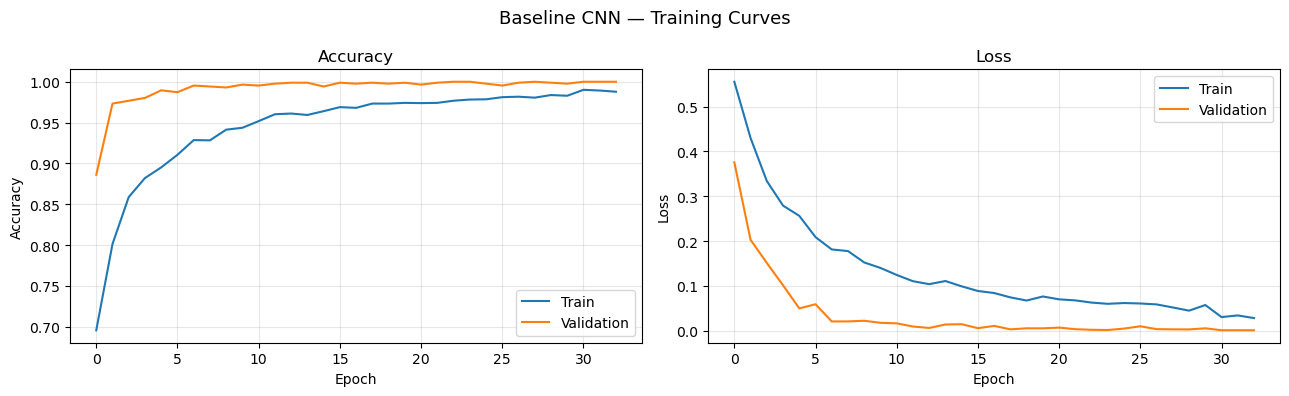

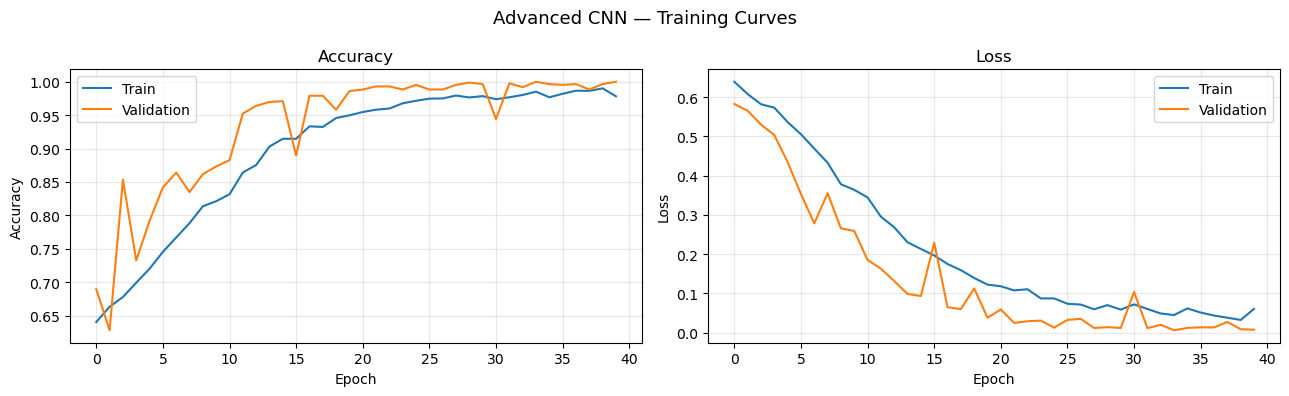

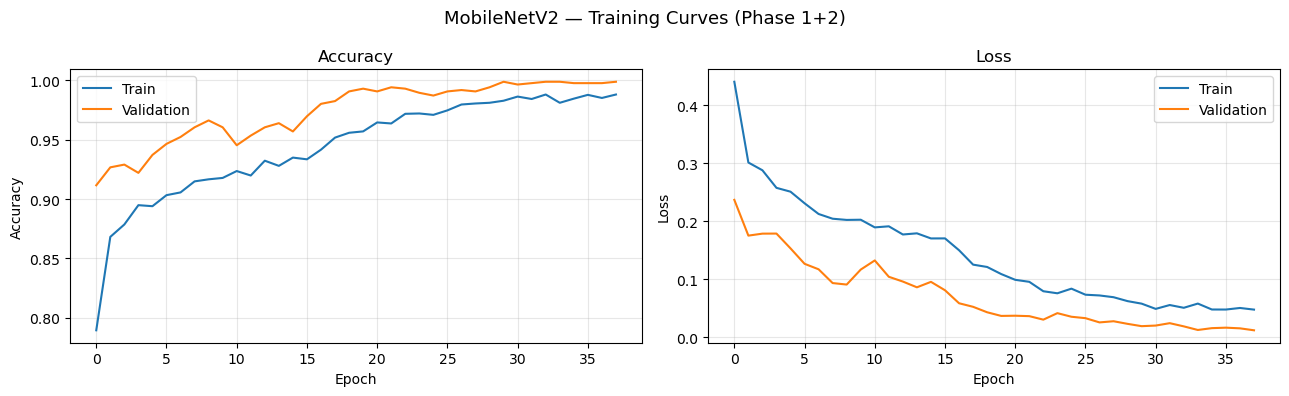

In [103]:
# Training curves for all three models
plot_training_curves("baseline_cnn", baseline_history,  title="Baseline CNN — Training Curves")
plot_training_curves("advanced_cnn", advanced_history,  title="Advanced CNN — Training Curves")
plot_training_curves("mobilenet_v2", merged_mobilenet,  title="MobileNetV2 — Training Curves (Phase 1+2)")


────────────────────────────────────────
  Baseline CNN
  Accuracy : 1.0000    AUC-ROC : 1.0000
────────────────────────────────────────
              precision    recall  f1-score   support

       alert       1.00      1.00      1.00       386
      drowsy       1.00      1.00      1.00       474

    accuracy                           1.00       860
   macro avg       1.00      1.00      1.00       860
weighted avg       1.00      1.00      1.00       860



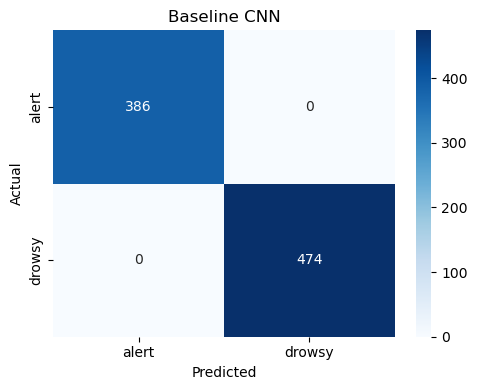


────────────────────────────────────────
  Advanced CNN
  Accuracy : 1.0000    AUC-ROC : 1.0000
────────────────────────────────────────
              precision    recall  f1-score   support

       alert       1.00      1.00      1.00       386
      drowsy       1.00      1.00      1.00       474

    accuracy                           1.00       860
   macro avg       1.00      1.00      1.00       860
weighted avg       1.00      1.00      1.00       860



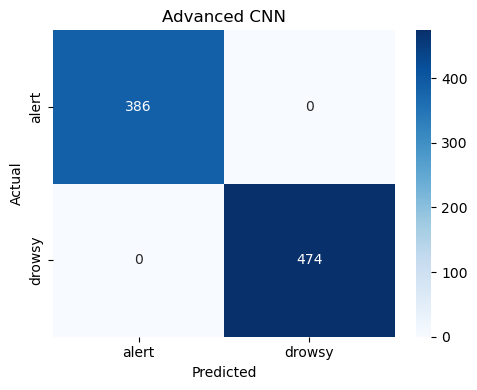


────────────────────────────────────────
  MobileNetV2
  Accuracy : 0.9988    AUC-ROC : 1.0000
────────────────────────────────────────
              precision    recall  f1-score   support

       alert       1.00      1.00      1.00       386
      drowsy       1.00      1.00      1.00       474

    accuracy                           1.00       860
   macro avg       1.00      1.00      1.00       860
weighted avg       1.00      1.00      1.00       860



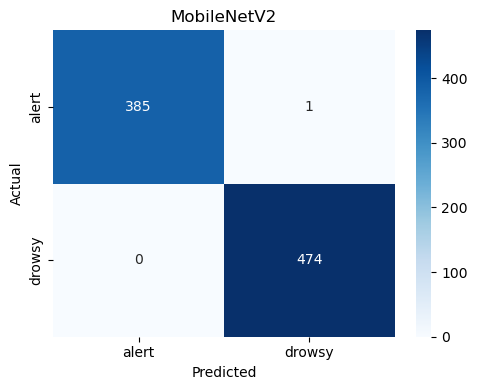

In [105]:
# Per-model metrics & confusion matrices
_, val_loader_eval, _ = build_loaders(augment=False)

results = {}

acc, auc = evaluate_model("baseline_cnn", baseline_model, val_loader_eval, "Baseline CNN")
results["Baseline CNN"] = dict(accuracy=acc, auc=auc)

acc, auc = evaluate_model("advanced_cnn", advanced_model, val_loader_eval, "Advanced CNN")
results["Advanced CNN"] = dict(accuracy=acc, auc=auc)

acc, auc = evaluate_model("mobilenet_v2", mobilenet_model, val_loader_eval, "MobileNetV2")
results["MobileNetV2"]  = dict(accuracy=acc, auc=auc)

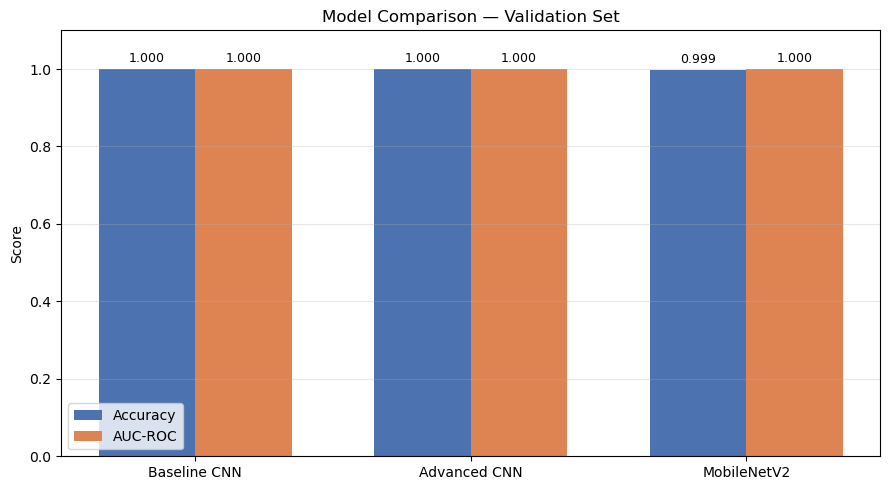


Final comparison:
  Baseline CNN          acc=1.0000  auc=1.0000
  Advanced CNN          acc=1.0000  auc=1.0000
  MobileNetV2           acc=0.9988  auc=1.0000


In [107]:
# Side-by-side comparison bar chart
labels_ = list(results.keys())
accs    = [results[n]["accuracy"] for n in labels_]
aucs    = [results[n]["auc"]      for n in labels_]
x       = np.arange(len(labels_))
w       = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, accs, w, label="Accuracy",  color="#4C72B0")
b2 = ax.bar(x + w/2, aucs, w, label="AUC-ROC",   color="#DD8452")

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score"); ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison — Validation Set")
ax.set_xticks(x); ax.set_xticklabels(labels_)
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(EVAL_DIR / "model_comparison.png"), dpi=150)
plt.show()

print("\nFinal comparison:")
for name in labels_:
    print(f"  {name:20s}  acc={results[name]['accuracy']:.4f}  auc={results[name]['auc']:.4f}")

In [109]:
# Verify saved models exist
print("Saved models:")
for f in sorted(SAVED_DIR.glob("*.pt")):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}  ({size_mb:.1f} MB)")
print("\nRun:  streamlit run app.py")

Saved models:
  advanced_cnn_best.pt  (5.1 MB)
  baseline_cnn_best.pt  (9.8 MB)
  mobilenet_v2_best.pt  (10.6 MB)
  mobilenet_v2_phase1_best.pt  (10.6 MB)

Run:  streamlit run app.py
